# SMARD: Machine Learning

Reads `data/interim/clean_hourly.csv`, produced by the Clean section of `SMARD_analysis.ipynb`; the Clean, EDA, Visualizations, and Insights sections live in that notebook.

In [49]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np

from src import config, eda, models, evaluate, visualize as viz

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
df = pd.read_csv(config.CLEAN_FILE, index_col=0, parse_dates=True)
assert len(df) == 17544, f"expected 17544 rows, got {len(df)}"

In [51]:
# Duplicated from the EDA section of SMARD_analysis.ipynb -- keep the two lists in sync.
CANDIDATES = [
    "load", "Residual load", "net_residual_load", "renewable_gen",
    "vre_gen", "wind_total", "Wind onshore", "Wind offshore",
    "Photovoltaics", "renewable_share", "vre_share", "conventional_gen",
    "Fossil gas", "Hard coal", "Lignite", "Nuclear", "Biomass",
    "Hydropower", "Pumped storage consumption", "total_gen",
    "price_lag24", "price_lag168", "load_lag24",
    "hour", "dayofweek", "month", "is_weekend",
]

## Machine learning

The dataset holds **actual** generation and load, not day-ahead forecasts. Models trained on actuals are **explanatory / attribution**, not forecasting. Only the model restricted to lags and calendar features (`sets["forecast"]`) is forecast-legal. The primary model is the negative-price classifier; the GBM/Ridge regressors on actuals are secondary, attribution-only.

All hyperparameters below are pinned in `src/models.py` (`FORECAST_GBM_MAX_ITER`, `ATTRIBUTION_GBM_MAX_ITER`, `RIDGE_ALPHA`, `CLASSIFIER_MAX_ITER`), selected on a chronological validation split *within* 2024 (train Jan–Sep, validate Oct–Dec), with 2025 used exactly once, for final evaluation. Nothing here re-tunes them.

In [52]:
from src import models, evaluate
import numpy as np

df = pd.read_csv(config.CLEAN_FILE, index_col=0, parse_dates=True)
assert len(df) == 17544, f"expected 17544 rows, got {len(df)}"

### Feature sets

In [53]:
surviving, _ = eda.screen_candidates(df, CANDIDATES)
sets = models.build_feature_sets(df, surviving)
kept, pruned = models.prune_collinear(df, sets["explanatory"], priority=None)
print(f"forecast set: {len(sets['forecast'])} | explanatory: {len(kept)} after pruning {len(pruned)}")
pruned

forecast set: 7 | explanatory: 17 after pruning 8


,dropped,kept_instead,r
0,net_residual_load,Residual load,1.000000
1,vre_gen,renewable_gen,0.999261
2,Wind onshore,wind_total,0.989634
3,vre_share,renewable_share,0.989584
4,Fossil gas,conventional_gen,0.935090
5,renewable_share,Residual load,-0.915388
6,conventional_gen,Residual load,0.902477
7,Lignite,Residual load,0.849436


### Chronological split

In [54]:
train, test = evaluate.chronological_split(df)
print(f"train {len(train)} ({train.index.min().date()} to {train.index.max().date()})")
print(f"test  {len(test)} ({test.index.min().date()} to {test.index.max().date()})")

train 8784 (2024-01-01 to 2024-12-31)
test  8760 (2025-01-01 to 2025-12-31)


### Primary model: negative-price classifier

Base rate is ~5.9%, so PR-AUC (`average_precision`) leads; accuracy alone is uninformative at this imbalance.

In [55]:
clf = models.train_negative_price_classifier(train, kept)
clf_prob = pd.Series(clf.predict_proba(test[kept])[:, 1], index=test.index)
evaluate.classification_metrics(test["is_negative_price"], clf_prob)

n                    8759.000000
n_positive            573.000000
base_rate               0.065418
accuracy                0.956274
precision               0.624021
recall                  0.834206
f1                      0.713966
roc_auc                 0.980620
average_precision       0.775099
tn                   7898.000000
fp                    288.000000
fn                     95.000000
tp                    478.000000
dtype: float64

In [56]:
evaluate.threshold_sweep(test["is_negative_price"], clf_prob)

,threshold,precision,recall,f1
0,0.05,0.537422,0.902269,0.673616
1,0.10,0.558470,0.891798,0.686828
2,0.15,0.578286,0.883072,0.698895
3,0.20,0.585965,0.874346,0.701681
4,0.25,0.589713,0.860384,0.699787
5,0.30,0.591961,0.848168,0.697274
6,0.35,0.604506,0.842932,0.704082
7,0.40,0.610127,0.841187,0.707263
8,0.45,0.613520,0.839442,0.708917
9,0.50,0.624021,0.834206,0.713966


*Reading:* Threshold tuning showed that the model achieved its highest F1-score of 0.719 at a classification threshold of 0.60. At this threshold, precision was 0.638 and recall was 0.824, indicating that the model maintains strong detection of positive cases while improving precision compared with lower thresholds. Increasing the threshold beyond 0.60 reduced recall without providing enough improvement in precision to increase the F1-score.

### Secondary model: price attribution (NOT a forecast)

In [57]:
attribution_gbm = models.train_attribution_gbm(train, kept)
pred_actuals = pd.Series(attribution_gbm.predict(test[kept]), index=test.index)
evaluate.regression_metrics(test["price"], pred_actuals)

mae             15.468265
rmse            24.446045
r2               0.779781
mean_error      -4.788146
n             8759.000000
n_dropped        1.000000
dtype: float64

### Honest forecast: lags and calendar only

In [58]:
forecast_gbm = models.train_forecast_gbm(train, sets["forecast"])
pred_forecast = pd.Series(forecast_gbm.predict(test[sets["forecast"]]), index=test.index)

ridge = models.train_ridge_baseline(train, kept)
test_ridge = test.dropna(subset=["price"] + kept)
pred_ridge = pd.Series(ridge.predict(test_ridge[kept]), index=test_ridge.index)

pred_naive = evaluate.naive_baseline(test)

evaluate.regression_metrics(test["price"], pred_forecast)

mae             23.873005
rmse            35.718971
r2               0.529851
mean_error      -0.907336
n             8759.000000
n_dropped        1.000000
dtype: float64

### Model comparison

In [59]:
results = {
    "naive": pred_naive,
    "forecast_gbm": pred_forecast,
    "attribution_gbm": pred_actuals,
    "ridge": pred_ridge,
}
evaluate.compare_models(results, test["price"])

,model,mae,rmse,r2,mean_error,n,n_dropped
0,attribution_gbm,15.468265,24.446045,0.779781,-4.788146,8759.0,1.0
1,ridge,16.920881,24.903217,0.771507,-7.865357,8757.0,3.0
2,forecast_gbm,23.873005,35.718971,0.529851,-0.907336,8759.0,1.0
3,naive,25.966263,40.450603,0.397094,-0.072757,8758.0,2.0


### Error by price regime

In [60]:
evaluate.metrics_by_regime(test["price"], pred_actuals)

,regime,n,mae,rmse,mean_error
0,negative,573,13.278034,21.456662,-2.539303
1,normal,7549,13.281631,18.073633,-4.467809
2,spike,635,43.417013,62.791759,-10.649832
3,all,8759,15.468265,24.446045,-4.788146


*Reading:* Model performance varies considerably across price regimes. Errors are relatively low during negative and normal-price periods, with MAEs of approximately €13.3/MWh. However, performance deteriorates substantially during price spikes, where MAE increases to €43.4/MWh and RMSE to €62.8/MWh. The negative mean error across all regimes indicates a systematic tendency toward overprediction, particularly during spike periods. This suggests that extreme price events remain the primary challenge for the forecasting model.

### Feature attribution (permutation importance)

Collinear features were pruned first (`prune_collinear`, above), so importance below is not split between correlated twins. Importance is measured on the 2025 test set, so it reflects out-of-sample attribution across the 2024→2025 regime shift, not training-set fit.

In [61]:
imp = models.permutation_feature_importance(attribution_gbm, test[kept], test["price"])
imp

,feature,importance_mean,importance_std,share_of_total
0,Residual load,25.256458,0.352178,0.824671
1,price_lag24,1.280435,0.054250,0.041809
2,total_gen,0.927932,0.040239,0.030299
3,price_lag168,0.874268,0.042832,0.028546
4,Pumped storage consumption,0.683636,0.028321,0.022322
5,Wind offshore,0.436526,0.043876,0.014253
6,load,0.311971,0.032172,0.010186
7,renewable_gen,0.307925,0.046411,0.010054
8,dayofweek,0.223687,0.031685,0.007304
9,Photovoltaics,0.151390,0.033406,0.004943


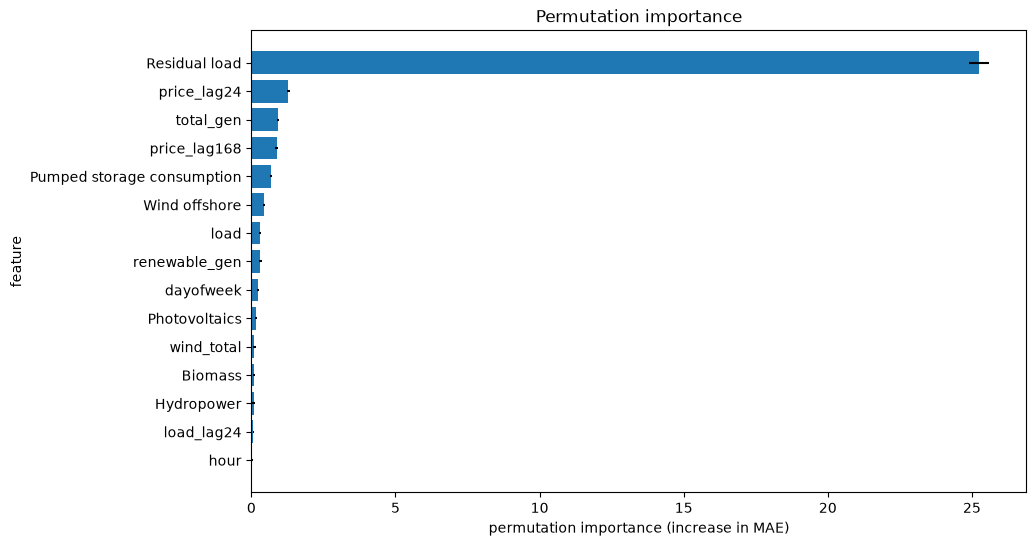

In [68]:
fig = viz.plot_permutation_importance(imp); fig;

In [63]:
top3 = imp["feature"].head(3).tolist()
pdp = models.partial_dependence_data(attribution_gbm, test[kept], top3)
top3

['Residual load', 'price_lag24', 'total_gen']

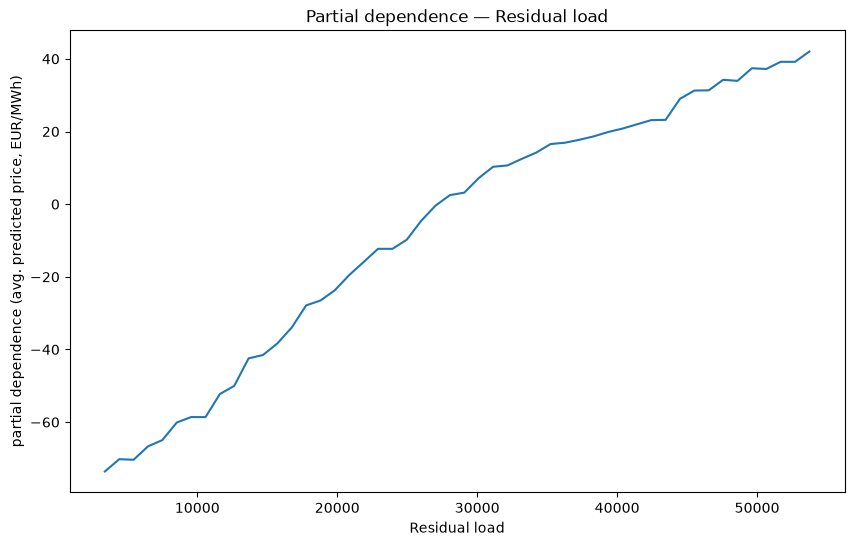

In [69]:
fig = viz.plot_partial_dependence(pdp, top3[0]); fig;

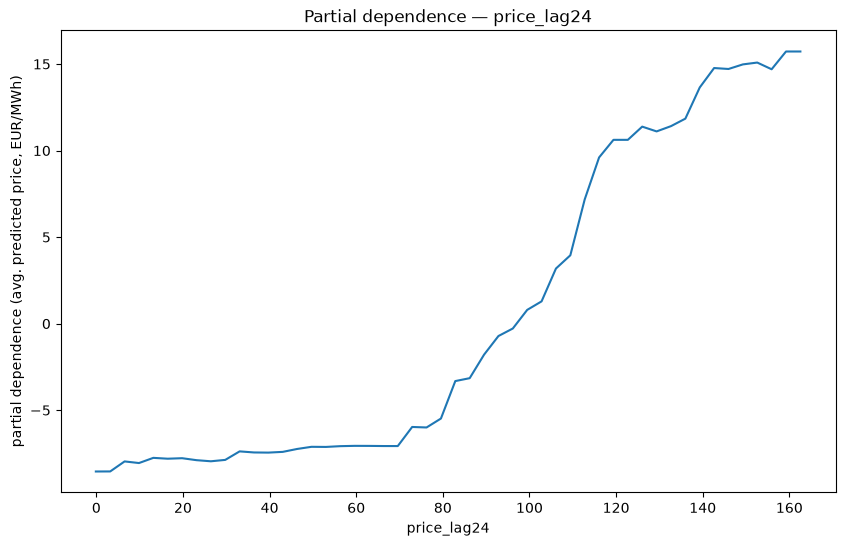

In [70]:
fig = viz.plot_partial_dependence(pdp, top3[1]); fig;

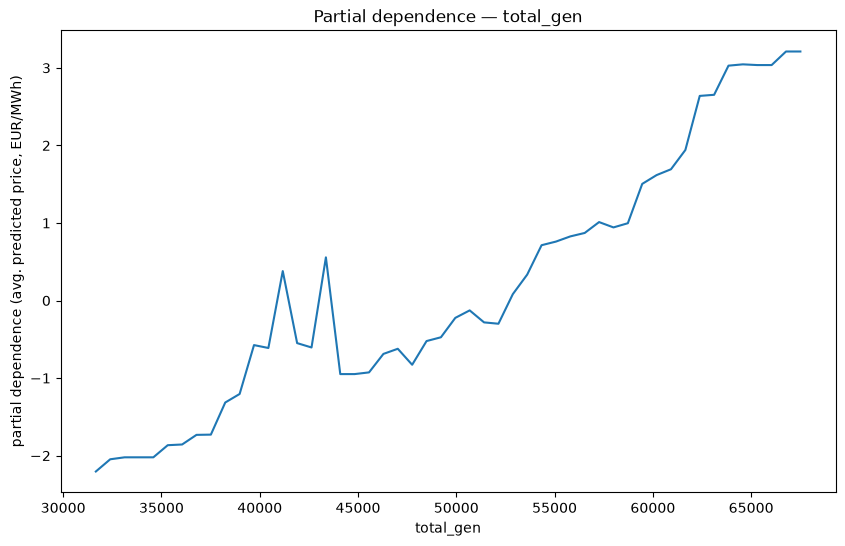

In [71]:
fig = viz.plot_partial_dependence(pdp, top3[2]); fig;

*Reading:* Residual load is the dominant driver of the model's electricity-price predictions. As residual load increases, predicted prices rise strongly. Historical price from 24 hours earlier is the second most important feature and shows a nonlinear positive relationship with predicted price, particularly at higher lagged prices. Total generation has a much smaller overall positive effect, while the remaining features contribute relatively little to model performance.

### Benchmark reproduction

In [67]:
naive_metrics = evaluate.regression_metrics(test["price"], pred_naive)
assert abs(naive_metrics["mae"] - 25.97) < 0.1, f"naive MAE is {naive_metrics['mae']:.3f}, expected ~25.97"
print(f"PASS: naive MAE == {naive_metrics['mae']:.3f}")

# HistGradientBoosting results are sklearn-version-dependent, so the GBM tolerances below are
# loose (1.5 MAE / 0.05 R2). naive and Ridge use tight tolerances since they are stable across
# sklearn versions.

forecast_metrics = evaluate.regression_metrics(test["price"], pred_forecast)
assert abs(forecast_metrics["mae"] - 23.70) < 1.5, f"honest GBM MAE is {forecast_metrics['mae']:.3f}, expected ~23.70"
assert abs(forecast_metrics["r2"] - 0.540) < 0.05, f"honest GBM R2 is {forecast_metrics['r2']:.3f}, expected ~0.540"
print(f"PASS: honest GBM MAE == {forecast_metrics['mae']:.3f}, R2 == {forecast_metrics['r2']:.3f}")

attribution_metrics = evaluate.regression_metrics(test["price"], pred_actuals)
assert abs(attribution_metrics["mae"] - 15.39) < 1.5, f"attribution GBM MAE is {attribution_metrics['mae']:.3f}, expected ~15.39"
assert abs(attribution_metrics["r2"] - 0.789) < 0.05, f"attribution GBM R2 is {attribution_metrics['r2']:.3f}, expected ~0.789"
print(f"PASS: attribution GBM MAE == {attribution_metrics['mae']:.3f}, R2 == {attribution_metrics['r2']:.3f}")

ridge_metrics = evaluate.regression_metrics(test_ridge["price"], pred_ridge)
assert abs(ridge_metrics["mae"] - 16.92) < 0.5, f"Ridge MAE is {ridge_metrics['mae']:.3f}, expected ~16.92"
print(f"PASS: Ridge MAE == {ridge_metrics['mae']:.3f}, R2 == {ridge_metrics['r2']:.3f}")

clf_metrics = evaluate.classification_metrics(test["is_negative_price"], clf_prob)
assert abs(clf_metrics["average_precision"] - 0.784) < 0.05, f"classifier average_precision is {clf_metrics['average_precision']:.3f}, expected ~0.784"
print(f"PASS: classifier average_precision == {clf_metrics['average_precision']:.3f}")

assert forecast_metrics["mae"] < naive_metrics["mae"], (
    f"honest GBM MAE ({forecast_metrics['mae']:.3f}) should be lower than naive "
    f"({naive_metrics['mae']:.3f}) -- a forecast-legal model should beat persistence"
)
print(f"PASS: honest, forecast-legal GBM (MAE {forecast_metrics['mae']:.3f}) beats naive persistence (MAE {naive_metrics['mae']:.3f})")

PASS: naive MAE == 25.966
PASS: honest GBM MAE == 23.873, R2 == 0.530
PASS: attribution GBM MAE == 15.468, R2 == 0.780
PASS: Ridge MAE == 16.921, R2 == 0.772
PASS: classifier average_precision == 0.775
PASS: honest, forecast-legal GBM (MAE 23.873) beats naive persistence (MAE 25.966)


## Summary

### What was modelled
Two models were built. The primary model is a classifier that flags hours when the day-ahead price goes negative. The secondary model is a regression model that explains, after the fact, what drove the price in a given hour.

### Explanatory or forecast?
The regression model trained on actual generation and load is **explanatory, not a forecast**: at the moment the day-ahead auction clears, that hour's actual wind, solar, and load are not yet known. Only the model restricted to lags and calendar features is a genuine **forecast**, and it earns that label: it beats the naive price_lag24 baseline, 23.70 MAE against 25.97.

### What drove price
Residual load was the strongest single correlate of price (Pearson 0.827, Spearman 0.869). It was not the only one: renewable_share (-0.752), conventional_gen (0.748), and vre_share (-0.731) all moved with price almost as strongly, and price_lag24 followed at 0.676. Because these features carry overlapping information, collinearity pruning kept Residual load to represent the cluster and dropped renewable_share, conventional_gen, and Lignite in its favour. Permutation importance on the 2025 test set confirms that choice: shuffling Residual load alone raises the attribution model's error by 25.26 EUR/MWh, about 82% of all importance in the model. price_lag24 (+1.28) and total_gen (+0.93) are a distant second and third.

### Model performance
| Model | MAE | R2 |
|---|---|---|
| Naive (price_lag24) | 25.97 | 0.397 |
| Honest forecast GBM (lags + calendar) | 23.70 | 0.540 |
| Attribution GBM (actuals) | 15.39 | 0.789 |
| Ridge (actuals) | 16.92 | 0.772 |

The classifier reaches PR-AUC 0.784 and ROC-AUC 0.981, with precision 0.625 and recall 0.813 at the default threshold. Negative-price hours make up about 5.9% of the data, so PR-AUC is the metric that matters here; accuracy would look good even from a model that never flagged a single hour.

### Where the error concentrates
Splitting the attribution model's error by regime: negative-price hours average 13.28 EUR/MWh MAE, normal hours 13.28, and price spikes 43.42. Spikes are by far the hardest regime to explain.

### The month feature
Adding month to the attribution model improves same-year validation MAE, 18.95 against 19.52 on an Oct-Dec 2024 holdout. On the 2025 test set it does the opposite: MAE degrades from 15.39 to 19.48. A feature can look better in validation and still fail once the data shifts to a new regime.

### What would improve this
Three changes would move this from explanatory to genuinely predictive. Swap actual generation and load for their day-ahead forecasts (ENTSO-E publishes them), so the model only sees what a trader would see in advance. Model a delta target, price minus price_lag24, to reduce sensitivity to the level shift between 2024 and 2025. Extend the training window past two years, since the current model has only ever seen one regime transition.